## Try 10.3.1: Agglomerative clustering in Python.

**Sometimes, a more convenient way of structuring the data for clustering is by using a distance matrix. The agglomerative clustering model can take in a distance matrix as input by using the squareform function from the spatial.distance package.**

**The Python code below uses agglomerative clustering to cluster species based on differences in the cytochrome c protein.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**
* **Change the clustering method from "single" to "complete" and "centroid", and examine the dendrogram for changes in the clusters.**

In [2]:
# Import packages and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [4]:
# Load the dataset
cytochrome = pd.read_csv('cytochrome.csv', header=None, usecols=range(1, 14))
cytochrome

,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0,1,12,10,11,10,9,10,13,14,11,15,18
1,1,0,11,9,10,9,8,11,12,13,10,14,17
2,12,11,0,3,6,5,6,7,11,13,10,11,14
3,10,9,3,0,3,2,4,6,9,11,8,9,11
4,11,10,6,3,0,3,5,7,10,11,8,9,12
5,10,9,5,2,3,0,2,6,9,10,7,8,11
6,9,8,6,4,5,2,0,6,8,9,6,9,11
7,10,11,7,6,7,6,6,0,12,11,10,11,13
8,13,12,11,9,10,9,8,12,0,3,3,8,11
9,14,13,13,11,11,10,9,11,3,0,4,9,13


In [5]:
# Add labels for each species and save as a data frame
species = [
    "Human",
    "Monkey",
    "Horse",
    "Cow",
    "Dog",
    "Whale",
    "Rabbit",
    "Kangaroo",
    "Chicken",
    "Penguin",
    "Duck",
    "Turtle",
    "Frog",
]

pd.DataFrame(data=cytochrome.to_numpy(), index=species, columns=species)

,Human,Monkey,Horse,Cow,Dog,Whale,Rabbit,Kangaroo,Chicken,Penguin,Duck,Turtle,Frog
Human,0,1,12,10,11,10,9,10,13,14,11,15,18
Monkey,1,0,11,9,10,9,8,11,12,13,10,14,17
Horse,12,11,0,3,6,5,6,7,11,13,10,11,14
Cow,10,9,3,0,3,2,4,6,9,11,8,9,11
Dog,11,10,6,3,0,3,5,7,10,11,8,9,12
Whale,10,9,5,2,3,0,2,6,9,10,7,8,11
Rabbit,9,8,6,4,5,2,0,6,8,9,6,9,11
Kangaroo,10,11,7,6,7,6,6,0,12,11,10,11,13
Chicken,13,12,11,9,10,9,8,12,0,3,3,8,11
Penguin,14,13,13,11,11,10,9,11,3,0,4,9,13


In [8]:
# Format the data as a distance matrix
# In this case, the data already represents distance between points (species)
differences = squareform(cytochrome)
differences

array([ 1, 12, 10, 11, 10,  9, 10, 13, 14, 11, 15, 18, 11,  9, 10,  9,  8,
       11, 12, 13, 10, 14, 17,  3,  6,  5,  6,  7, 11, 13, 10, 11, 14,  3,
        2,  4,  6,  9, 11,  8,  9, 11,  3,  5,  7, 10, 11,  8,  9, 12,  2,
        6,  9, 10,  7,  8, 11,  6,  8,  9,  6,  9, 11, 12, 11, 10, 11, 13,
        3,  3,  8, 11,  4,  9, 13,  7, 11, 10])

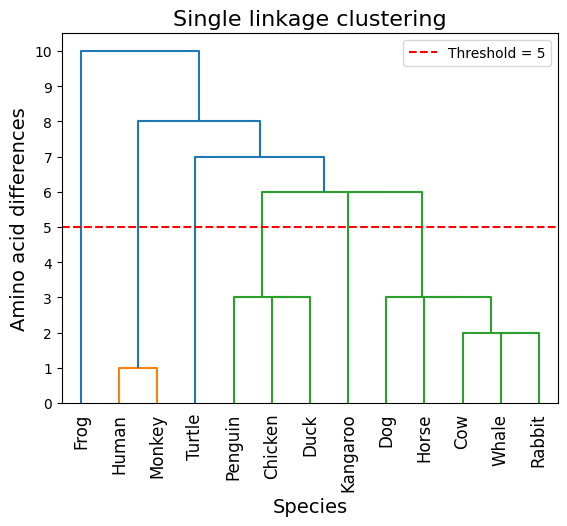

In [12]:
# Define a clustering model with single linkage
clusterModel = linkage(differences, method='single')

# Create the dendrogram
dendrogram(clusterModel, labels=species, leaf_rotation=90)

# Add threshold line to cut clades
threshold = 5
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')

# Plot the dendrogram
plt.ylabel('Amino acid differences', fontsize=14)
plt.yticks(np.arange(0, 11, step=1))
plt.xlabel('Species', fontsize=14)
plt.title('Single linkage clustering', fontsize=16)
plt.legend()
plt.show()

In [14]:
# Analyze clusters at different thresholds
from scipy.cluster.hierarchy import fcluster

for thresh in [3, 4, 5, 6, 7]:
    clusters = fcluster(clusterModel, thresh, criterion='distance')
    n_clusters = len(set(clusters))
    print(f"Threshold {thresh}: {n_clusters} clusters")
    print(f"Cluster assignments: {clusters}")
    print()

Threshold 3: 6 clusters
Cluster assignments: [1 1 3 3 3 3 3 4 2 2 2 5 6]

Threshold 4: 6 clusters
Cluster assignments: [1 1 3 3 3 3 3 4 2 2 2 5 6]

Threshold 5: 6 clusters
Cluster assignments: [1 1 3 3 3 3 3 4 2 2 2 5 6]

Threshold 6: 4 clusters
Cluster assignments: [1 1 2 2 2 2 2 2 2 2 2 3 4]

Threshold 7: 3 clusters
Cluster assignments: [1 1 2 2 2 2 2 2 2 2 2 2 3]



## challenge activity | 10.3.2: Hierarchical clustering using scipy and scikit-learn.

## 1)
**Researchers studying chemical properties of wines collected data on a sample of white wines in Northern Portugal. A research goal was to cluster wines based on similar chemical properties.**

* **Cluster wines with centroid linkage.**

  
**The code provided creates a dataframe with two features (pH and sulphates), normalizes the dataframe, creates a distance matrix, and displays the cluster membership of each data point.**

In [ ]:
import pandas as pd

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

wine = pd.read_csv('wine1.csv')

# Calculate a distance matrix with selected variables
X = wine[['pH', 'sulphates']]

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))

# pdist() calculates pairs of distances between each instance in the dataset
dist = pdist(X)

# Your code goes here

print(clusterModel)

## 2) 
**Researchers studying chemical properties of wines collected data on a sample of white wines in Northern Portugal. A research goal was to cluster wines based on similar chemical properties.**

* **Using pdist(), calculate a distance matrix for wines. The matrix of input features, X, has already been created.**

* **Use the distance matrix to cluster the wines with complete linkage.**

**The code provided creates a dataframe with two features (quality and sulphates), normalizes the dataframe, and displays the cluster membership of each data point.**

In [ ]:
import pandas as pd

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

wine = pd.read_csv('wine1.csv')

# Calculate a distance matrix with selected variables
X = wine[['quality', 'sulphates']]

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))

# Your code goes here

print(clusterModel)